# 8장 실습 — 액션 청킹은 왜 존재하는가

3부는 방향을 바꾼다. 2부가 모델을 작게 만들었다면, 3부는 **지연을 전제로 설계한다.**

그 첫 장치가 액션 청킹이다. 한 번 물어서 한 걸음이 아니라 **여러 걸음을 한꺼번에** 받아 오는 것이다.

흔한 오해를 먼저 고쳐야 한다. **ACT 와 Diffusion Policy 는 청킹을 지연 은닉으로 제안하지 않았다.** ACT 논문이 적은 동기는 「과제의 유효 지평을 k 분의 1 로 줄여 누적 오차를 완화한다」이고, 사람 시연의 비마르코프성 — 시연 중간의 멈춤 같은 것 — 을 다루기 위해서이기도 하다. 청킹을 **지연을 숨기는 장치로 재해석한 것은 RTC(NeurIPS 2025)** 다.

이 노트북은 그 두 동기를 갈라 잰다. 청킹이 성적을 올리는가, 아니면 **다른 것을 사 주는가.**

실행 시간은 CPU에서 6분 안팎이다.

In [1]:
%pip install -q mujoco==3.13.0 koreanize-matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import copy
import time
import unicodedata
import numpy as np
import mujoco
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import koreanize_matplotlib  # noqa: F401


def dw(s):
    return sum(2 if unicodedata.east_asian_width(c) in "WF" else 1
               for c in str(s))


def pad(s, n, right=False):
    gap = " " * max(n - dw(s), 0)
    return gap + str(s) if right else str(s) + gap


def wilson(k, n, z=1.96):
    if n == 0:
        return 0., 0.
    ph = k / n
    d = 1 + z * z / n
    c = ph + z * z / (2 * n)
    h = z * ((ph * (1 - ph) + z * z / (4 * n)) / n) ** .5
    return (c - h) / d, (c + h) / d


RED, GREY, INK = "#E32C24", "#8C8A85", "#1C1C1A"
PINK = "#F3A29D"
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": .25, "axes.spines.top": False,
                     "axes.spines.right": False})
torch.set_num_threads(2)
print("mujoco", mujoco.__version__, "/ torch", torch.__version__)

mujoco 3.13.0 / torch 2.14.0+cu130


In [3]:
XML = '''
<mujoco model="planar_push">
  <option timestep="0.004" integrator="implicitfast"/>
  <worldbody>
    <geom name="floor" type="plane" size="3 3 .1"
          friction=".6 .005 .0001"/>
    <body name="block" pos="0 0 .031">
      <freejoint/>
      <geom type="cylinder" size=".03 .03" mass=".25"
            friction=".6 .005 .0001"/>
    </body>
    <body name="pusher" pos="0 0 .03">
      <joint name="px" type="slide" axis="1 0 0"/>
      <joint name="py" type="slide" axis="0 1 0"/>
      <geom type="cylinder" size=".012 .03" mass="4"/>
    </body>
  </worldbody>
  <actuator>
    <velocity joint="px" kv="120"/>
    <velocity joint="py" kv="120"/>
  </actuator>
</mujoco>
'''

EP, GOAL_R, AMAX = 110, .03, .35
MODEL = mujoco.MjModel.from_xml_string(XML)


class Vec:
    def __init__(self, n, seed=0, hz=20):
        self.m = MODEL
        self.sub = int(round(1 / hz / self.m.opt.timestep))
        self.n = n
        self.d = [mujoco.MjData(self.m) for _ in range(n)]
        self.g = np.zeros((n, 2))
        self.t = np.zeros(n, int)
        self.db = np.zeros(n)
        self.dp = np.zeros(n)
        self.rng = np.random.default_rng(seed)
        for i in range(n):
            self.reset(i)

    def reset(self, i):
        d = self.d[i]
        mujoco.mj_resetData(self.m, d)
        bx, by = self.rng.uniform(-.03, .03, 2)
        d.qpos[0:2] = [bx, by]
        d.qpos[2] = .031
        d.qpos[7:9] = [bx - .09, by]
        mujoco.mj_forward(self.m, d)
        jit = self.rng.uniform(-.04, .04, 2)
        self.g[i] = np.array([.30, 0.]) + jit
        self.t[i] = 0
        self.db[i] = np.linalg.norm(d.qpos[0:2] - self.g[i])
        self.dp[i] = np.linalg.norm(d.qpos[7:9] - d.qpos[0:2])

    def obs(self):
        o = np.empty((self.n, 8), np.float32)
        for i, d in enumerate(self.d):
            b = np.asarray(d.qpos[0:2], float)
            o[i, 0:2] = self.g[i] - b
            o[i, 2:4] = d.qvel[0:2]
            o[i, 4:6] = b - d.qpos[7:9]
            o[i, 6:8] = d.qvel[6:8]
        return o * np.float32(10.)

    def step(self, a):
        r = np.zeros(self.n, np.float32)
        dn = np.zeros(self.n, np.float32)
        sc = []
        for i, d in enumerate(self.d):
            d.ctrl[:] = np.clip(a[i], -1, 1) * AMAX
            for _ in range(self.sub):
                mujoco.mj_step(self.m, d)
            db = np.linalg.norm(d.qpos[0:2] - self.g[i])
            dp = np.linalg.norm(d.qpos[7:9] - d.qpos[0:2])
            r[i] = (10 * (self.db[i] - db) + 2 * (self.dp[i] - dp)
                    + (.3 if db < GOAL_R else 0.))
            self.db[i], self.dp[i] = db, dp
            self.t[i] += 1
            if self.t[i] >= EP:
                dn[i] = 1.
                sc.append(float(db < GOAL_R))
                self.reset(i)
        return r, dn, sc

In [4]:
class AC(nn.Module):
    def __init__(self, din=8):
        super().__init__()
        self.pi = nn.Sequential(nn.Linear(din, 64), nn.Tanh(),
                                nn.Linear(64, 64), nn.Tanh(),
                                nn.Linear(64, 2))
        self.v = nn.Sequential(nn.Linear(din, 64), nn.Tanh(),
                               nn.Linear(64, 64), nn.Tanh(),
                               nn.Linear(64, 1))
        self.ls = nn.Parameter(torch.zeros(2) - .5)

    def dist(self, o):
        return torch.distributions.Normal(self.pi(o), self.ls.exp())


def train_rl(budget=250_000, seed=0, n=16, T=32, lr=3e-3):
    torch.manual_seed(seed)
    env = Vec(n, seed)
    ac = AC()
    opt = torch.optim.Adam(ac.parameters(), lr)
    o = env.obs()
    steps = 0
    while steps < budget:
        O = np.empty((T, n, 8), np.float32)
        A = np.empty((T, n, 2), np.float32)
        LP = np.empty((T, n), np.float32)
        R = np.empty((T, n), np.float32)
        V = np.empty((T + 1, n), np.float32)
        D = np.empty((T, n), np.float32)
        for t in range(T):
            ot = torch.from_numpy(o)
            with torch.no_grad():
                di = ac.dist(ot)
                a = di.sample()
                LP[t] = di.log_prob(a).sum(-1).numpy()
                V[t] = ac.v(ot).squeeze(-1).numpy()
            O[t], A[t] = o, a.numpy()
            R[t], D[t], _ = env.step(A[t])
            o = env.obs()
        with torch.no_grad():
            V[T] = ac.v(torch.from_numpy(o)).squeeze(-1).numpy()
        steps += T * n
        adv = np.zeros((T, n), np.float32)
        g = 0.
        for t in reversed(range(T)):
            nt = 1. - D[t]
            dl = R[t] + .99 * V[t + 1] * nt - V[t]
            g = dl + .99 * .95 * nt * g
            adv[t] = g
        rt = adv + V[:T]
        bo = torch.from_numpy(O.reshape(-1, 8))
        ba = torch.from_numpy(A.reshape(-1, 2))
        bl = torch.from_numpy(LP.reshape(-1))
        br = torch.from_numpy(rt.reshape(-1))
        bd = torch.from_numpy(adv.reshape(-1))
        bd = (bd - bd.mean()) / (bd.std() + 1e-8)
        nb = bo.shape[0]
        mb = max(64, nb // 4)
        for _ in range(4):
            idx = torch.randperm(nb)
            for k in range(0, nb, mb):
                j = idx[k:k + mb]
                di = ac.dist(bo[j])
                lp = di.log_prob(ba[j]).sum(-1)
                ratio = (lp - bl[j]).exp()
                l1 = ratio * bd[j]
                l2 = torch.clamp(ratio, .8, 1.2) * bd[j]
                vl = (ac.v(bo[j]).squeeze(-1) - br[j]) ** 2
                loss = (-torch.min(l1, l2).mean() + .5 * vl.mean()
                        - .003 * di.entropy().sum(-1).mean())
                opt.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(ac.parameters(), .5)
                opt.step()
    return ac


t0 = time.time()
POLICY = train_rl()
print(f"정책 학습 끝  ({time.time() - t0:.0f}s)")

정책 학습 끝  (66s)


In [5]:
class Pert(Vec):
    """배포 조건 — 관측 편향, 제어 지연, 다른 마찰"""

    def __init__(self, n, seed=0, bias=(0., 0.), lat=0, mu=.6):
        self.bias = np.asarray(bias)
        self.lat = lat
        super().__init__(n, seed)
        if mu != .6:
            xml = XML.replace('friction=".6', f'friction="{mu}')
            self.m = mujoco.MjModel.from_xml_string(xml)
            self.sub = int(round(1 / 20 / self.m.opt.timestep))
            self.d = [mujoco.MjData(self.m) for _ in range(n)]
            for i in range(n):
                self.reset(i)
        self.buf = [[np.zeros(2)] * (lat + 1) for _ in range(n)]

    def obs(self):
        o = super().obs()
        o[:, 0:2] -= np.float32(self.bias * 10.)
        o[:, 4:6] += np.float32(self.bias * 10.)
        return o

    def step(self, a):
        if self.lat:
            out = np.empty_like(a)
            for i in range(self.n):
                self.buf[i].append(a[i].copy())
                out[i] = self.buf[i][-1 - self.lat]
            a = out
        return super().step(a)


COND = {"명목": dict(),
        "배포": dict(bias=(.006, -.004), lat=1, mu=.80)}
print("평가 조건:", ", ".join(COND))

평가 조건: 명목, 배포


## 청크를 내놓는 정책

원래 정책은 관측 하나를 받아 행동 하나를 낸다. 청킹을 하려면 **관측 하나를 받아 앞으로 H 걸음을 한꺼번에** 내놓아야 한다.

교사의 궤적을 모아 그렇게 학습시킨다. 7장에서 본 대로 이 방식의 학생은 교사만큼은 못 하지만, 여기서 재려는 것은 절대 성적이 아니라 **H 를 바꿨을 때의 변화**다. 모든 H 가 같은 방식으로 학습되므로 비교가 성립한다.

In [6]:
HS = [1, 2, 4, 8, 16, 32]
HMAX = max(HS)


class Chunk(nn.Module):
    def __init__(self, h=HMAX):
        super().__init__()
        self.h = h
        self.f = nn.Sequential(nn.Linear(8, 128), nn.Tanh(),
                               nn.Linear(128, 128), nn.Tanh(),
                               nn.Linear(128, 2 * h))

    def forward(self, o):
        return self.f(o).view(-1, self.h, 2)


def collect(teacher, n=32, steps=600, seed=3):
    """관측과 그 뒤 HMAX 걸음의 교사 행동을 짝지어 모은다"""
    torch.manual_seed(seed)
    env = Vec(n, seed)
    O, A = [], []
    for _ in range(steps + HMAX):
        o = env.obs()
        ot = torch.from_numpy(o)
        with torch.no_grad():
            a = teacher.dist(ot).sample().numpy()   # 굴릴 때는 표본
            m = teacher.pi(ot).numpy()              # 배울 때는 평균
        O.append(o)
        A.append(m)
        env.step(a)
    O = np.stack(O)
    A = np.stack(A)
    X, Y = [], []
    for t in range(steps):
        X.append(O[t])
        Y.append(A[t:t + HMAX].transpose(1, 0, 2))
    return (torch.from_numpy(np.concatenate(X)),
            torch.from_numpy(np.concatenate(Y)))


def train_chunk(X, Y, epochs=120, seed=3):
    torch.manual_seed(seed)
    m = Chunk()
    opt = torch.optim.Adam(m.parameters(), 2e-3)
    n = X.shape[0]
    for _ in range(epochs):
        idx = torch.randperm(n)
        for k in range(0, n, 2048):
            j = idx[k:k + 2048]
            loss = ((m(X[j]) - Y[j]) ** 2).mean()
            opt.zero_grad()
            loss.backward()
            opt.step()
    return m


t0 = time.time()
X, Y = collect(POLICY)
print(f"시연 {X.shape[0]:,}개  ({time.time() - t0:.0f}s)")
CH = train_chunk(X, Y)
print(f"청크 정책 학습 끝  ({time.time() - t0:.0f}s)")

시연 19,200개  (3s)


청크 정책 학습 끝  (9s)


## H 를 바꿔 가며 굴린다

**H 걸음마다 한 번만 묻고**, 그 사이에는 받아 둔 청크를 그대로 실행한다. H=1 이면 매 스텝 묻는 것이고, H=32 면 32 스텝을 눈감고 가는 것이다.

5장·6장과 같은 두 조건에서 잰다.

In [7]:
def run_chunk(model, H, cond, seed=999, n=150, reps=2):
    torch.manual_seed(seed)
    env = Pert(n, seed, **COND[cond])
    buf = np.zeros((n, HMAX, 2), np.float32)
    left = np.zeros(n, int)
    sc, queries, steps = [], 0, 0
    for t in range(EP * reps):
        need = left <= 0
        if need.any():
            with torch.no_grad():
                out = model(torch.from_numpy(env.obs())).numpy()
            buf[need] = out[need]
            left[need] = H
            queries += int(need.sum())
        idx = H - left
        a = buf[np.arange(n), np.clip(idx, 0, HMAX - 1)]
        left -= 1
        steps += n
        sc += env.step(a)[2]
    return np.array(sc), queries / steps


t0 = time.time()
RES = {}
for H in HS:
    for c in COND:
        RES[(H, c)] = run_chunk(CH, H, c)
    print(f"H={H} 끝  ({time.time() - t0:.0f}s)")

print()
print(pad("청크 길이", 12) + pad("질의 주기", 12, True)
      + pad("질의당 예산", 14, True) + pad("명목", 9, True)
      + pad("배포", 9, True) + pad("배포 95% 구간", 18, True))
for H in HS:
    sc, _ = RES[(H, "배포")]
    lo, hi = wilson(sc.sum(), len(sc))
    print(pad(f"H = {H}", 12)
          + pad(f"{20 / H:.1f} Hz", 12, True)
          + pad(f"{50 * H:.0f} ms", 14, True)
          + pad(f"{RES[(H, '명목')][0].mean():.2f}", 9, True)
          + pad(f"{sc.mean():.2f}", 9, True)
          + pad(f"[{lo:.2f}, {hi:.2f}]", 18, True))
print()
print("제어 주기는 20 Hz 고정  ·  조건마다 300판")

H=1 끝  (10s)


H=2 끝  (20s)


H=4 끝  (29s)


H=8 끝  (38s)


H=16 끝  (47s)


H=32 끝  (55s)

청크 길이      질의 주기   질의당 예산     명목     배포     배포 95% 구간
H = 1            20.0 Hz         50 ms     0.94     0.74      [0.69, 0.79]
H = 2            10.0 Hz        100 ms     0.87     0.10      [0.07, 0.14]
H = 4             5.0 Hz        200 ms     0.81     0.02      [0.01, 0.04]
H = 8             2.5 Hz        400 ms     0.23     0.01      [0.00, 0.03]
H = 16            1.2 Hz        800 ms     0.03     0.00      [0.00, 0.01]
H = 32            0.6 Hz       1600 ms     0.01     0.00      [0.00, 0.01]

제어 주기는 20 Hz 고정  ·  조건마다 300판


## 청킹이 사 주는 것

세 번째 열이 이 장의 답이다. **H 를 키우면 질의당 예산이 그만큼 늘어난다.**

H=1 이면 50 밀리초 안에 추론이 끝나야 한다. H=8 이면 400 밀리초가 있다. 1장에서 본 π₀ 의 프리필 46 밀리초와 50 Hz 제어 주기 20 밀리초의 간극이 여기서 메워진다 — **모델을 빠르게 만든 것이 아니라 예산을 늘린 것이다.**

성공률 열은 다른 말을 한다. 청킹이 성적을 올려 주지 않는다. 짧은 H 에서 높고 길어질수록 내려간다.

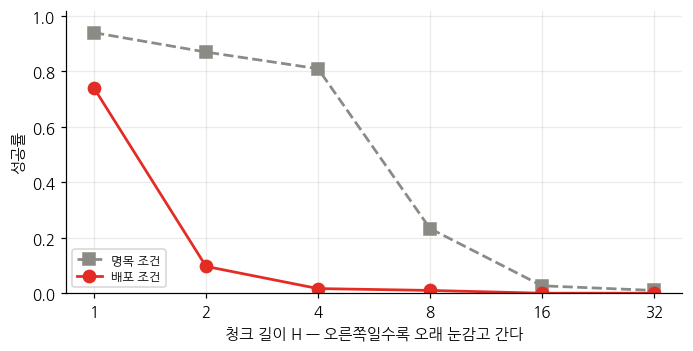

In [8]:
fig, ax = plt.subplots(figsize=(6.4, 3.3))
for c, col, mk in (("명목", GREY, "s--"), ("배포", RED, "o-")):
    ax.plot(HS, [RES[(H, c)][0].mean() for H in HS], mk,
            color=col, lw=1.8, ms=8, label=f"{c} 조건")
ax.set_xscale("log", base=2)
ax.set_xticks(HS)
ax.set_xticklabels([str(h) for h in HS])
ax.set_xlabel("청크 길이 H — 오른쪽일수록 오래 눈감고 간다")
ax.set_ylabel("성공률")
ax.set_ylim(0, 1.02)
ax.legend(fontsize=8, loc="lower left")
plt.tight_layout()
plt.show()

## ACT 의 원래 동기는 재현되는가

ACT 논문의 청크 길이 제거 실험은 **k=1 에서 1%, k=100 에서 44%** 였다. 길게 할수록 좋아진 것이다. 우리 결과와 방향이 반대다.

조건이 다르기 때문이다. ACT 가 다룬 것은 **사람의 시연**이고, 사람은 중간에 멈추거나 망설이거나 같은 상황에서 다르게 움직인다. 그 비마르코프성 아래에서는 한 걸음씩 흉내 내는 정책이 흔들리고, 청크로 묶으면 안정된다. 우리 교사는 결정적인 신경망이라 그 문제가 없다.

실험으로 확인해 본다. 교사의 행동에 **상관 있는 잡음** — 사람의 망설임을 흉내 낸 것 — 을 얹어 시연을 다시 모으고, 같은 스윕을 돌린다.

In [9]:
def collect_wobbly(teacher, n=32, steps=600, seed=3,
                   rho=.9, sd=.35):
    torch.manual_seed(seed)
    env = Vec(n, seed)
    rng = np.random.default_rng(seed)
    w = np.zeros((n, 2))
    O, A = [], []
    for _ in range(steps + HMAX):
        o = env.obs()
        with torch.no_grad():
            a = teacher.dist(torch.from_numpy(o)).sample().numpy()
        w = rho * w + (1 - rho) * rng.normal(0, sd, (n, 2)) * 10
        a = a + w.astype(np.float32)
        O.append(o)
        A.append(a)
        env.step(a)
    O = np.stack(O)
    A = np.stack(A)
    X, Y = [], []
    for t in range(steps):
        X.append(O[t])
        Y.append(A[t:t + HMAX].transpose(1, 0, 2))
    return (torch.from_numpy(np.concatenate(X)),
            torch.from_numpy(np.concatenate(Y)))


t0 = time.time()
Xw, Yw = collect_wobbly(POLICY)
CHW = train_chunk(Xw, Yw)
print(f"흔들리는 시연으로 학습 끝  ({time.time() - t0:.0f}s)")

print()
print(pad("청크 길이", 12) + pad("결정적 시연", 14, True)
      + pad("흔들리는 시연", 16, True))
for H in (1, 2, 4, 8, 16):
    a = RES[(H, "명목")][0].mean()
    b = run_chunk(CHW, H, "명목")[0].mean()
    print(pad(f"H = {H}", 12) + pad(f"{a:.2f}", 14, True)
          + pad(f"{b:.2f}", 16, True))

흔들리는 시연으로 학습 끝  (9s)

청크 길이      결정적 시연   흔들리는 시연


H = 1                 0.94            0.03


H = 2                 0.87            0.25


H = 4                 0.81            0.25


H = 8                 0.23            0.11


H = 16                0.03            0.01


## 정리

**청킹의 원래 동기와 지금의 용도가 다르다.** ACT 는 누적 오차와 시연의 비마르코프성을 위해 제안했고, RTC 가 그것을 지연 은닉 장치로 재해석했다. 두 동기를 섞어 인용하면 안 된다.

**청킹은 성적을 올려 주지 않는다 — 예산을 늘려 준다.** H=8 이면 질의당 400 밀리초가 생긴다. 모델을 빠르게 만든 것이 아니라 마감을 옮긴 것이다.

**대가는 반응성이다.** 청크를 실행하는 동안 새 관측을 보지 않으므로, H 가 길수록 무너진다. 교란이 있으면 더 빨리 무너진다.

**시연이 흔들리면 청킹이 값을 한다.** 결정적인 교사에게서는 그 이득이 나오지 않는다. 자기 데이터가 어느 쪽인지가 H 의 선택을 바꾼다.

그런데 H 를 키우면서 반응성을 지킬 방법이 있다. 겹치는 청크를 섞는 것이다. 다음 장이 그 값과 **비용**을 잰다.